<a href="https://colab.research.google.com/github/Alaa-f-Abdalaal/Machine-Projectss/blob/main/anhanced_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Class counts:
 assistance_type
medical                 15296
food                    11441
financial               11332
education                7669
housing                  7494
disability_equipment     3756
Name: count, dtype: int64
Training the pipeline...
Training complete!

Accuracy: 0.9586769608703282
Macro F1: 0.9585274142565456

Classification Report:

                      precision    recall  f1-score   support

disability_equipment       0.97      0.95      0.96       751
           education       0.96      0.96      0.96      1534
           financial       0.96      0.96      0.96      2267
                food       0.95      0.97      0.96      2288
             housing       0.96      0.96      0.96      1499
             medical       0.96      0.96      0.96      3059

            accuracy                           0.96     11398
           macro avg       0.96      0.96      0.96     11398
        weighted avg       0.96      0.96      0.96     11398



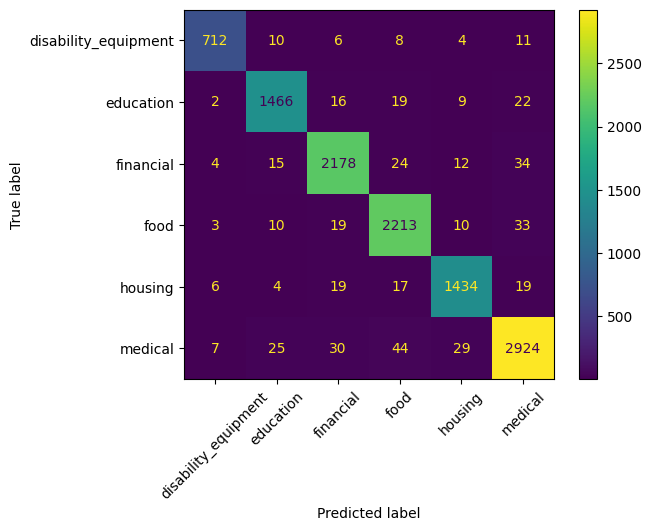

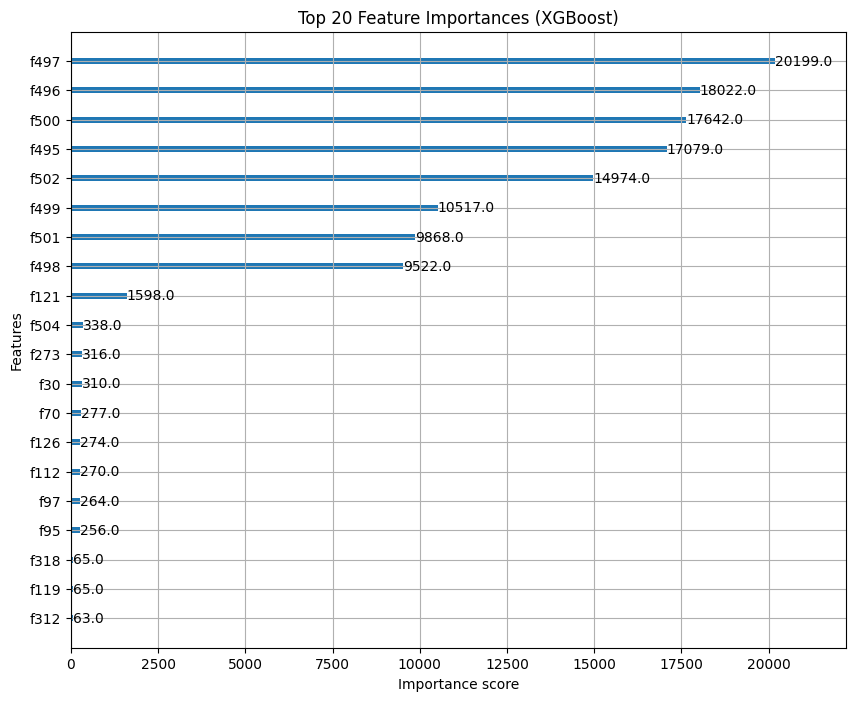


--- Manual Tests ---
Text: I need medical treatment urgently
Prediction: medical
Probabilities: [[0.03369566 0.28587407 0.06977763 0.13160288 0.16514955 0.31390023]]

Text: I cannot pay school fees
Prediction: education
Probabilities: [[0.02172825 0.28962487 0.11743926 0.17449318 0.22012249 0.17659196]]

Text: أنا محتاج علاج طبي بشكل عاجل
Prediction: medical
Probabilities: [[0.03369566 0.28587407 0.06977763 0.13160288 0.16514955 0.31390023]]



In [ ]:
# 1. INSTALLATIONS (Run once)
# ==============================
!pip install scikit-learn xgboost imbalanced-learn matplotlib pandas numpy -q

# 2. IMPORTS
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, accuracy_score, f1_score, ConfusionMatrixDisplay
from xgboost import XGBClassifier, plot_importance

# IMPORTANT: We use the Pipeline from imblearn, NOT sklearn, so it can handle the oversampler
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import RandomOverSampler

# 3. LOAD DATA
# ==============================
df = pd.read_excel('/content/Awnn_feature_engineering (1).xlsx')

drop_cols = ['name','national_id','phone','city','neighborhood','recommended_org']
df = df.drop(columns=drop_cols, errors='ignore')

df = df[df['assistance_type'] != 'unknown'].reset_index(drop=True)
df['request_text'] = df['request_text'].astype(str)

print("Class counts:\n", df['assistance_type'].value_counts())

# 4. SETUP FEATURES & TARGET
# ==============================
structured_features = [
    'financial_gap','hardship_score','income_stability','family_size','children_ratio',
    'economic_pressure','debt_to_income_ratio','remaining_income','is_deficit','critical_case'
]

# We keep text and structured features in a single dataframe for the pipeline
X = df[['request_text'] + structured_features]
y = df['assistance_type']

# 5. TRAIN-TEST SPLIT
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Encode labels
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

# 6. BUILD THE PREPROCESSING & MODELING PIPELINE
# ==============================
# The ColumnTransformer applies different preprocessing to different columns
preprocessor = ColumnTransformer(
    transformers=[
        ('text_tfidf', TfidfVectorizer(max_features=8000, ngram_range=(1,2), min_df=1), 'request_text'),
        ('num_scaler', StandardScaler(), structured_features)
    ])

# The Pipeline ensures data flows in the exact right order without leakage
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('oversampler', RandomOverSampler(random_state=42)),
    ('classifier', XGBClassifier(
        n_estimators=500,
        max_depth=8,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='mlogloss',
        objective='multi:softprob'
    ))
])

# 7. TRAIN THE MODEL
# ==============================
print("Training the pipeline...")
pipeline.fit(X_train, y_train_enc)
print("Training complete!")

# 8. EVALUATION
# ==============================
y_pred = pipeline.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test_enc, y_pred))
print("Macro F1:", f1_score(y_test_enc, y_pred, average='macro'))

print("\nClassification Report:\n")
print(classification_report(y_test_enc, y_pred, target_names=le.classes_))

ConfusionMatrixDisplay.from_predictions(y_test_enc, y_pred, display_labels=le.classes_)
plt.xticks(rotation=45)
plt.show()

# 9. FEATURE IMPORTANCE PLOT
# ==============================
# Extract the trained XGBoost model from the pipeline
xgb_model = pipeline.named_steps['classifier']

# Plot the top 20 most important features
fig, ax = plt.subplots(figsize=(10, 8))
plot_importance(xgb_model, max_num_features=20, ax=ax, title="Top 20 Feature Importances (XGBoost)")
plt.show()

# Note: The feature names in the plot will be generic (e.g., f0, f1, f2).
# The last 10 features (f8000 to f8009) correspond to your 10 structured_features.
# The features from f0 to f7999 correspond to your TF-IDF text vocabulary.

# 10. PREDICTION FUNCTION
# ==============================
def predict_case(text, structured_values):
    # Create a single-row DataFrame matching the exact structure expected by the pipeline
    input_data = [text] + list(structured_values)
    columns = ['request_text'] + structured_features
    input_df = pd.DataFrame([input_data], columns=columns)

    # The pipeline handles all TF-IDF vectorization and scaling automatically
    pred_prob = pipeline.predict_proba(input_df)
    pred_class = np.argmax(pred_prob, axis=1)

    return le.classes_[pred_class[0]], pred_prob

# 11. TEST PREDICTIONS
# ==============================
examples = [
    ("I need medical treatment urgently", [4000,0.9,0.2,5,0.6,0.7,0.5,-800,1,1]),
    ("I cannot pay school fees", [1000,0.4,0.7,3,0.4,0.3,0.2,200,0,0]),
    ("أنا محتاج علاج طبي بشكل عاجل", [4000,0.9,0.2,5,0.6,0.7,0.5,800,1,1])
]

print("\n--- Manual Tests ---")
for text, struct_vals in examples:
    pred, prob = predict_case(text, struct_vals)
    print(f"Text: {text}\nPrediction: {pred}\nProbabilities: {prob}\n")

In [ ]:
!pip install scikit-learn xgboost pandas numpy sentence-transformers -q

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score
from xgboost import XGBClassifier
from sentence_transformers import SentenceTransformer

# Load Data
df = pd.read_excel('/content/Awnn_feature_engineering (1).xlsx')

# Clean out unknowns and ensure text is string
df = df[df['assistance_type'] != 'unknown'].reset_index(drop=True)
df['request_text'] = df['request_text'].astype(str)

print("Total rows:", len(df))
print(df['assistance_type'].value_counts())

Total rows: 56988
assistance_type
medical                 15296
food                    11441
financial               11332
education                7669
housing                  7494
disability_equipment     3756
Name: count, dtype: int64


In [ ]:
# Load the Multilingual Embedding Model
print("Downloading Multilingual Model...")
embedder = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

# Generate Embeddings (This takes a few seconds on a GPU)
print("Encoding text into vectors...")
X_embeddings = embedder.encode(df['request_text'].tolist(), show_progress_bar=True)

# Encode the Target Labels
le = LabelEncoder()
y_encoded = le.fit_transform(df['assistance_type'])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Encoding text into vectors...


Batches:   0%|          | 0/1781 [00:00<?, ?it/s]

In [ ]:
# Split the embeddings into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_embeddings, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Training shape: {X_train.shape}")
print(f"Testing shape: {X_test.shape}")

Training shape: (45590, 384)
Testing shape: (11398, 384)


In [ ]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    random_state=42,
    eval_metric='mlogloss',
    objective='multi:softprob',
    tree_method='hist' # Makes training much faster!
)

print("Training XGBoost on Text Embeddings...")
xgb_model.fit(X_train, y_train)
print("Training Complete!")

Training XGBoost on Text Embeddings...
Training Complete!


In [ ]:
y_pred = xgb_model.predict(X_test)

print("\n--- TEXT-ONLY MODEL ACCURACY ---")
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))


--- TEXT-ONLY MODEL ACCURACY ---
Accuracy: 0.9654325320231619

Classification Report:

                      precision    recall  f1-score   support

disability_equipment       1.00      0.95      0.97       751
           education       1.00      0.95      0.97      1534
           financial       1.00      0.95      0.97      2267
                food       1.00      0.96      0.98      2288
             housing       1.00      0.95      0.97      1499
             medical       0.89      1.00      0.94      3059

            accuracy                           0.97     11398
           macro avg       0.98      0.96      0.97     11398
        weighted avg       0.97      0.97      0.97     11398



In [ ]:
def predict_arabic_text(text):
    # Convert text to vector
    vector = embedder.encode([text])

    # Predict
    pred_prob = xgb_model.predict_proba(vector)
    pred_class = np.argmax(pred_prob, axis=1)

    # Output
    label = le.classes_[pred_class[0]]
    confidence = np.max(pred_prob) * 100

    print(f"Text: '{text}'")
    print(f"Prediction: {label} (Confidence: {confidence:.2f}%)\n")

print("--- MANUAL TESTS ---")
predict_arabic_text("أنا محتاج علاج طبي بشكل عاجل")
predict_arabic_text("مش قادر أدفع مصاريف مدرسة ولادي")
predict_arabic_text("نحتاج سلة غذائية للأسرة")
predict_arabic_text("عليا ديون ومش قادر أسدد الإيجار")

--- MANUAL TESTS ---
Text: 'أنا محتاج علاج طبي بشكل عاجل'
Prediction: medical (Confidence: 99.95%)

Text: 'مش قادر أدفع مصاريف مدرسة ولادي'
Prediction: education (Confidence: 97.47%)

Text: 'نحتاج سلة غذائية للأسرة'
Prediction: food (Confidence: 98.98%)

Text: 'عليا ديون ومش قادر أسدد الإيجار'
Prediction: education (Confidence: 58.39%)



In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# 1. Define the numerical features (So Python doesn't forget!)
structured_features = [
    'financial_gap','hardship_score','income_stability','family_size','children_ratio',
    'economic_pressure','debt_to_income_ratio','remaining_income','is_deficit','critical_case'
]

# Extract the numerical features
X_structured = df[structured_features]

# Scale the numbers (important for XGBoost and distance metrics)
scaler = StandardScaler()
X_structured_scaled = scaler.fit_transform(X_structured)

# 2. Split everything perfectly in sync
# We pass X_embeddings AND X_structured_scaled so they split at the exact same indices
X_text_train, X_text_test, X_num_train, X_num_test, y_train, y_test = train_test_split(
    X_embeddings, X_structured_scaled, y_encoded,
    test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Text Train shape: {X_text_train.shape}")
print(f"Num Train shape: {X_num_train.shape}")

Text Train shape: (45590, 384)
Num Train shape: (45590, 10)


In [ ]:
# 3. Train "The Reader" (Text Model)
xgb_text = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    random_state=42, eval_metric='mlogloss', objective='multi:softprob',
    tree_method='hist'
)
print("Training Text Model...")
xgb_text.fit(X_text_train, y_train)

# 4. Train "The Accountant" (Numerical Model)
# We can use shallower trees here since it's just 10 numbers
xgb_num = XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    random_state=42, eval_metric='mlogloss', objective='multi:softprob'
)
print("Training Numerical Model...")
xgb_num.fit(X_num_train, y_train)

print("Both models trained successfully!")

Training Text Model...
Training Numerical Model...
Both models trained successfully!


In [ ]:
# 5. Get probabilities from both models on the Test Set
prob_text = xgb_text.predict_proba(X_text_test)
prob_num = xgb_num.predict_proba(X_num_test)

# 6. LATE FUSION: Weighted Average of Probabilities
# Text gets 75% voting power, Numbers get 25% voting power
weight_text = 0.75
weight_num = 0.25

prob_final = (prob_text * weight_text) + (prob_num * weight_num)

# 7. Get the final predicted class (the one with the highest combined probability)
y_pred_final = np.argmax(prob_final, axis=1)

print("\n--- FUSION MODEL ACCURACY ---")
print("Accuracy:", accuracy_score(y_test, y_pred_final))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_final, target_names=le.classes_))


--- FUSION MODEL ACCURACY ---
Accuracy: 0.9654325320231619

Classification Report:

                      precision    recall  f1-score   support

disability_equipment       1.00      0.95      0.97       751
           education       1.00      0.95      0.97      1534
           financial       1.00      0.95      0.97      2267
                food       1.00      0.96      0.98      2288
             housing       1.00      0.95      0.97      1499
             medical       0.89      1.00      0.94      3059

            accuracy                           0.97     11398
           macro avg       0.98      0.96      0.97     11398
        weighted avg       0.97      0.97      0.97     11398



In [ ]:
def predict_case_fusion(text, structured_values):
    # --- 1. Process Text ---
    text_vector = embedder.encode([text])
    text_prob = xgb_text.predict_proba(text_vector)

    # --- 2. Process Numbers ---
    num_df = pd.DataFrame([structured_values], columns=structured_features)
    num_scaled = scaler.transform(num_df)
    num_prob = xgb_num.predict_proba(num_scaled)

    # --- 3. Combine Votes ---
    final_prob = (text_prob * 0.75) + (num_prob * 0.25)
    pred_class = np.argmax(final_prob, axis=1)

    # --- 4. Output ---
    label = le.classes_[pred_class[0]]
    confidence = np.max(final_prob) * 100

    print(f"Text: '{text}'")
    print(f"Numbers: {structured_values}")
    print(f"Prediction: {label} (Confidence: {confidence:.2f}%)\n")
    print("-" * 40)

# Let's test the tricky one!
# Try it with numbers that suggest a heavy financial burden
print("\n--- MANUAL FUSION TESTS ---")

# "I have debts and can't pay rent" + High financial gap, high debt ratio
predict_case_fusion(
    "عليا ديون ومش قادر أسدد الإيجار",
    [4500, 0.9, 0.1, 4, 0.5, 0.8, 0.9, -1000, 1, 1]
)

# Same text, but with numbers that suggest a housing emergency (low debt, but critical case)
predict_case_fusion(
    "عليا ديون ومش قادر أسدد الإيجار",
    [500, 0.5, 0.6, 2, 0.0, 0.3, 0.2, 100, 0, 1]
)


--- MANUAL FUSION TESTS ---
Text: 'عليا ديون ومش قادر أسدد الإيجار'
Numbers: [4500, 0.9, 0.1, 4, 0.5, 0.8, 0.9, -1000, 1, 1]
Prediction: education (Confidence: 46.51%)

----------------------------------------
Text: 'عليا ديون ومش قادر أسدد الإيجار'
Numbers: [500, 0.5, 0.6, 2, 0.0, 0.3, 0.2, 100, 0, 1]
Prediction: education (Confidence: 45.50%)

----------------------------------------


# after enhanced

In [ ]:
!pip install scikit-learn xgboost pandas numpy sentence-transformers imbalanced-learn -q

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, accuracy_score
from xgboost import XGBClassifier
from sentence_transformers import SentenceTransformer

# Load Data
df = pd.read_excel('/content/Awnn_feature_engineering (1).xlsx')

# Clean out unused columns and unknowns
drop_cols = ['name','national_id','phone','city','neighborhood','recommended_org']
df = df.drop(columns=drop_cols, errors='ignore')
df = df[df['assistance_type'] != 'unknown'].reset_index(drop=True)
df['request_text'] = df['request_text'].astype(str)

print("Total rows:", len(df))
print(df['assistance_type'].value_counts())

Total rows: 56988
assistance_type
medical                 15296
food                    11441
financial               11332
education                7669
housing                  7494
disability_equipment     3756
Name: count, dtype: int64


In [ ]:
# 1. Define the numerical features explicitly
structured_features = [
    'financial_gap','hardship_score','income_stability','family_size','children_ratio',
    'economic_pressure','debt_to_income_ratio','remaining_income','is_deficit','critical_case'
]

# 2. Extract and scale the numerical features
X_structured = df[structured_features]
scaler = StandardScaler()
X_structured_scaled = scaler.fit_transform(X_structured)

# 3. Load the Multilingual Embedding Model
print("Downloading/Loading Multilingual Model...")
embedder = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

# 4. Generate Embeddings (Uses GPU)
print("Encoding Arabic text into vectors...")
X_embeddings = embedder.encode(df['request_text'].tolist(), show_progress_bar=True)

# 5. Encode the Target Labels
le = LabelEncoder()
y_encoded = le.fit_transform(df['assistance_type'])

Downloading/Loading Multilingual Model...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoding Arabic text into vectors...


Batches:   0%|          | 0/1781 [00:00<?, ?it/s]

In [ ]:
# Split both embeddings and numerical features at the exact same indices
X_text_train, X_text_test, X_num_train, X_num_test, y_train, y_test = train_test_split(
    X_embeddings, X_structured_scaled, y_encoded,
    test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Text Train shape: {X_text_train.shape}")
print(f"Num Train shape: {X_num_train.shape}")

Text Train shape: (45590, 384)
Num Train shape: (45590, 10)


In [ ]:
# Train "The Reader" (Text-only Model)
xgb_text = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    random_state=42, eval_metric='mlogloss', objective='multi:softprob',
    tree_method='hist'
)
print("Training Text Model...")
xgb_text.fit(X_text_train, y_train)

# Train "The Accountant" (Numerical-only Model)
xgb_num = XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    random_state=42, eval_metric='mlogloss', objective='multi:softprob'
)
print("Training Numerical Model...")
xgb_num.fit(X_num_train, y_train)

print("Both experts trained successfully!")

Training Text Model...
Training Numerical Model...
Both experts trained successfully!


In [ ]:
# Get probabilities from both models on the test set
prob_text = xgb_text.predict_proba(X_text_test)
prob_num = xgb_num.predict_proba(X_num_test)

# Static Fusion: Let's assume Text gets 75% voting power on average
prob_final = (prob_text * 0.75) + (prob_num * 0.25)
y_pred_final = np.argmax(prob_final, axis=1)

print("\n--- BASE FUSION MODEL ACCURACY ---")
print("Accuracy:", accuracy_score(y_test, y_pred_final))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_final, target_names=le.classes_))


--- BASE FUSION MODEL ACCURACY ---
Accuracy: 0.9654325320231619

Classification Report:

                      precision    recall  f1-score   support

disability_equipment       1.00      0.95      0.97       751
           education       1.00      0.95      0.97      1534
           financial       1.00      0.95      0.97      2267
                food       1.00      0.96      0.98      2288
             housing       1.00      0.95      0.97      1499
             medical       0.89      1.00      0.94      3059

            accuracy                           0.97     11398
           macro avg       0.98      0.96      0.97     11398
        weighted avg       0.97      0.97      0.97     11398



In [ ]:
# --- TESTING WITH REAL DATA ---
print("\n--- REAL DATA FUSION TESTS ---")

# 1. Find a real 'financial' row from the dataframe
real_financial_row = df[df['assistance_type'] == 'financial'].iloc[0]
real_fin_text = real_financial_row['request_text']
real_fin_numbers = real_financial_row[structured_features].tolist()

print("Testing a REAL Financial Case:")
predict_smart_routing(real_fin_text, real_fin_numbers)

# 2. Find a real 'housing' row from the dataframe
real_housing_row = df[df['assistance_type'] == 'housing'].iloc[0]
real_house_text = real_housing_row['request_text']
real_house_numbers = real_housing_row[structured_features].tolist()

print("Testing a REAL Housing Case:")
predict_smart_routing(real_house_text, real_house_numbers)


--- REAL DATA FUSION TESTS ---
Testing a REAL Financial Case:
Text: 'إبراهيم الهواري من أيتام مقيم في العطارين ويحتاج: تحتاج مساعدة مالية لتغطية مصاريف المعيشة'
Numbers: [np.float64(0.4755716319395615), np.float64(0.1152813919081244), np.float64(0.5094565532737468), np.int64(6), np.float64(-0.851528233115447), np.float64(-0.009089781413488098), np.float64(-0.5460450010774784), np.float64(-26430.0), np.int64(1), np.int64(0)]
System logic: Text was clear. Text took priority.
Prediction: financial (Confidence: 88.20%)

--------------------------------------------------
Testing a REAL Housing Case:
Text: 'يوسف شريف من أسرة فقيرة مقيم في فيصل ويحتاج: تحتاج مساعدة لدفع الإيجار أو ترميم السكن'
Numbers: [np.float64(-0.8045338563917951), np.float64(-0.6586388821551007), np.float64(-0.398260555516077), np.int64(2), np.float64(1.446237932090459), np.float64(-0.01229161889322429), np.float64(-0.5460450010774784), np.float64(-11890.0), np.int64(1), np.int64(0)]
System logic: Text was clear. Text t